# Luxury Watch Resale Price Analysis

This notebook performs exploratory data analysis (EDA) and modeling to understand the factors affecting the resale price of luxury watches.

I have a passion for mechanical watches, and have always been fascinated by the price movements in luxury watches. The question here is: 'What key combination of features (e.g. brand, movement, material, condition) most significantly affects the resale price of luxury watches?'

In this notebook, we will build regression modeling and try to find out the main features that impact the price (box, papers, brand, etc.)

I found two separate datasets that can serve the project, so we will analyze them. I downloaded them into csv files. Here are the original sources of the data:
- Luxury watch listings from Kaggle: https://www.kaggle.com/datasets/philmorekoung11/luxury-watch-listings
- Watch market datasets from Kaggle: https://www.kaggle.com/datasets/beridzeg45/watch-prices-dataset 

**Notebook outline**
1. Imports and setup
2. Dataset 1: cleaning, outlier analysis and EDA
3. Dataset 2: cleaning, outlier analysis, feature engineering and EDA
4. Modeling: baseline regression, evaluation and feature importance
5. Conclusions and next steps

## 1. Imports and Setup
All libraries are imported here with their standard aliases, and a shared plot style and price-axis formatter are defined.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

# Formats price axes as dollars (e.g. $12,500) instead of scientific notation
dollar_format = FuncFormatter(lambda value, _: f"${value:,.0f}")

## 2. Dataset 1: Luxury Watch Listings
### 2.1 Loading the data

In [74]:
df1 = pd.read_csv("data/Watches-ds-1.csv", low_memory=False)

# "Unnamed: 0" is just the row index saved with the CSV. It is unique per row,
# so duplicate detection cannot find any match until it is dropped.
print(f"Duplicate rows including the index column: {df1.duplicated().sum():,}")
df1 = df1.drop(columns="Unnamed: 0")
print(f"Duplicate rows after dropping it: {df1.duplicated().sum():,}")

print(f"Dataset 1 shape: {df1.shape}")
display(df1.head())

Duplicate rows including the index column: 0
Duplicate rows after dropping it: 11,398
Dataset 1 shape: (284491, 13)


,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


In [75]:
# Check the production years before cleaning. 'yop' is text such as "2022 (Approximation)",
# so the leading 4 characters are parsed as a number.
parsed_years = pd.to_numeric(df1["yop"].astype(str).str[:4], errors="coerce")
print(f"Earliest parsed year: {parsed_years.min():.0f}, latest: {parsed_years.max():.0f}")
print(f"Listings with a year before 1900: {(parsed_years < 1900).sum():,}")
print(f"Listings with a non-numeric year (e.g. 'Unknown'): {parsed_years.isna().sum():,}")

Earliest parsed year: 1559, latest: 2024
Listings with a year before 1900: 110
Listings with a non-numeric year (e.g. 'Unknown'): 96,091


### 2.2 Cleaning
Plan:
- **Price** is stored as text such as `$43,500`. Currency symbols and commas are stripped and the result converted to a number. Rows whose price cannot be converted are dropped, since price is the target variable.
- **Year of production** (`yop`) contains values like `2022 (Approximation)` or `Unknown`, so the 4-digit year is extracted and anything else becomes missing. The check above shows an implausible earliest year (1559), so a lower bound of 1900 is used; the upper bound is the latest year in the data (2024).
- **Condition** is split across two columns (`cond` and `condition`); they are merged into one.
- Missing categorical values are filled with `Unknown` and exact duplicate listings are removed.

In [76]:
def clean_price(price_series):
    """Strip currency symbols/commas and convert to float; non-numeric text becomes NaN."""
    stripped = price_series.astype(str).str.replace(r"[$£€,]", "", regex=True).str.strip()
    return pd.to_numeric(stripped, errors="coerce")


def clean_year(year_series):
    """Extract a plausible 4-digit production year; anything else becomes NaN."""
    years = pd.to_numeric(year_series.astype(str).str[:4], errors="coerce")
    return years.where(years.between(1900, 2024))


df1["price_clean"] = clean_price(df1["price"])

# Show which raw price values could not be converted
unparsed_prices = df1.loc[df1["price_clean"].isna(), "price"]
print(f"Listings without a numeric price: {len(unparsed_prices):,}")
display(unparsed_prices.value_counts(dropna=False).rename("listings").to_frame())
df1 = df1.dropna(subset=["price_clean"])

df1["year_clean"] = clean_year(df1["yop"])

# Merge the two condition columns, preferring 'cond' when both exist
df1["condition_clean"] = df1["cond"].fillna(df1["condition"])

categorical_cols1 = ["brand", "model", "mvmt", "casem", "bracem", "condition_clean", "sex", "size"]
df1[categorical_cols1] = df1[categorical_cols1].fillna("Unknown")

rows_before = len(df1)
df1 = df1.drop_duplicates()
print(f"Duplicate listings removed: {rows_before - len(df1):,}")
print(f"Dataset 1 shape after cleaning: {df1.shape}")

Listings without a numeric price: 14,665


,listings
price,
Price on request,14259
NaN,406


Duplicate listings removed: 8,977
Dataset 1 shape after cleaning: (260849, 16)


**Result:** 14,665 listings had no numeric price: 14,259 were marked *"Price on request"* and 406 were blank. They were dropped. Section 2.1 showed that dropping the index column reveals 11,398 duplicate rows; after the price-less listings were removed, 8,977 of those duplicates remained and were removed here.

### 2.3 Outlier analysis
Before choosing an outlier rule, the cell below checks what the standard 1.5 x IQR rule on **raw** price would remove, both overall and for four high-end brands.

In [77]:
def iqr_bounds(values, k):
    """Return the (lower, upper) bounds of the IQR rule with multiplier k."""
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


# What would the standard 1.5 x IQR rule on raw price remove?
raw_low, raw_high = iqr_bounds(df1["price_clean"], k=1.5)
raw_outlier = ~df1["price_clean"].between(raw_low, raw_high)
print(f"Raw-price IQR upper bound: ${raw_high:,.0f}")
print(f"Share of listings flagged: {raw_outlier.mean():.1%}")

share_flagged_by_brand = (
    raw_outlier.groupby(df1["brand"]).mean()
    .loc[["Rolex", "Patek Philippe", "Audemars Piguet", "Richard Mille"]]
    .rename("share_flagged_as_outlier")
)
display(share_flagged_by_brand.to_frame().style.format("{:.1%}"))

Raw-price IQR upper bound: $35,090
Share of listings flagged: 11.3%


,share_flagged_as_outlier
brand,
Rolex,16.0%
Patek Philippe,68.2%
Audemars Piguet,68.5%
Richard Mille,99.4%


In [78]:
# Let's take 50 as the minimum plausible price
MIN_PLAUSIBLE_PRICE = 50

# Look at the cheapest listings before choosing a price floor
below_floor1 = df1[df1["price_clean"] < MIN_PLAUSIBLE_PRICE]
print(f"Listings under ${MIN_PLAUSIBLE_PRICE}: {len(below_floor1):,}")
display(below_floor1[["brand", "model", "price_clean"]].head())

Listings under $50: 27


,brand,model,price_clean
224160,Seiko,Unknown,26.0
224161,Seiko,Unknown,32.0
224162,Seiko,Unknown,34.0
224163,Seiko,Unknown,34.0
224164,Seiko,Unknown,34.0


**Result:** the table shows the raw-price rule would discard most Patek Philippe, Audemars Piguet and Richard Mille listings, which would remove the luxury segment from the analysis instead of cleaning errors out of it. The cell above also shows that only a handful of listings are under $50, and they are inexpensive watches (e.g. Seiko). Two rules are used instead:

1. **Price floor:** listings under **$50** are removed. They are a negligible share of the data, fall outside the luxury segment this project studies, and in Dataset 2 include an implausible $1 listing (shown in section 3.2).
2. **Log-scale IQR (3 x IQR):** the IQR rule is applied to `log10(price)`, and with the wider 3 x multiplier conventionally used for *extreme* outliers. This only flags values that are implausible even on a multiplicative scale.

In [79]:
def remove_price_outliers(df, price_col):
    """Drop prices below the floor or outside 3 x IQR on the log10 scale."""
    log_price = np.log10(df[price_col])
    log_low, log_high = iqr_bounds(log_price, k=3)
    keep = (df[price_col] >= MIN_PLAUSIBLE_PRICE) & log_price.between(log_low, log_high)
    print(f"Lowest price: ${df[price_col].min():,.2f}; listings under the ${MIN_PLAUSIBLE_PRICE} floor: "
          f"{(df[price_col] < MIN_PLAUSIBLE_PRICE).sum():,}")
    print(f"Log-scale bounds: ${10 ** log_low:,.2f} to ${10 ** log_high:,.0f}")
    print(f"Rows removed: {(~keep).sum():,} ({(~keep).mean():.2%})")
    return df[keep].copy()


df1_clean = remove_price_outliers(df1, "price_clean")
print(f"Dataset 1 shape after outlier removal: {df1_clean.shape}")

Lowest price: $10.00; listings under the $50 floor: 27
Log-scale bounds: $19.66 to $2,389,665
Rows removed: 58 (0.02%)
Dataset 1 shape after outlier removal: (260791, 16)


### 2.4 EDA for Dataset 1

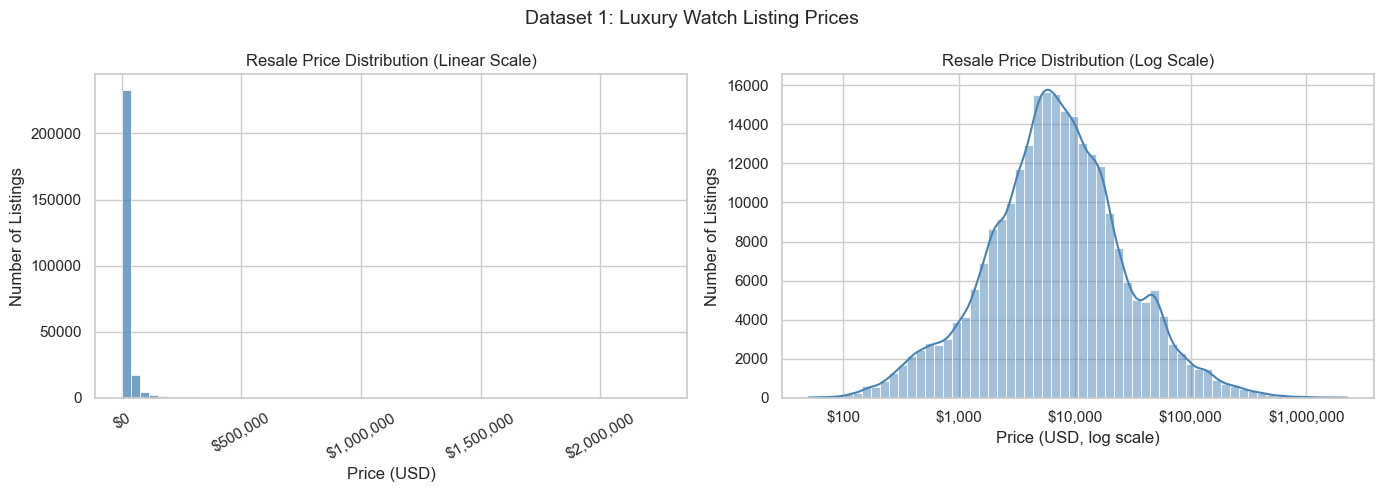

In [80]:
# Side-by-side view of the same prices on a linear and a log scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df1_clean["price_clean"], bins=60, color="steelblue", ax=axes[0])
axes[0].set_title("Resale Price Distribution (Linear Scale)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Number of Listings")
axes[0].xaxis.set_major_formatter(dollar_format)
axes[0].tick_params(axis="x", rotation=30)

sns.histplot(df1_clean["price_clean"], bins=60, log_scale=True, kde=True, color="steelblue", ax=axes[1])
axes[1].set_title("Resale Price Distribution (Log Scale)")
axes[1].set_xlabel("Price (USD, log scale)")
axes[1].set_ylabel("Number of Listings")
axes[1].xaxis.set_major_formatter(dollar_format)

fig.suptitle("Dataset 1: Luxury Watch Listing Prices", fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** On a linear scale nearly all listings are packed into the first few bars, with a long tail stretching past $100k. On a log scale the distribution is close to bell-shaped. This is why the correct target is `log10(price)` instead of raw price.

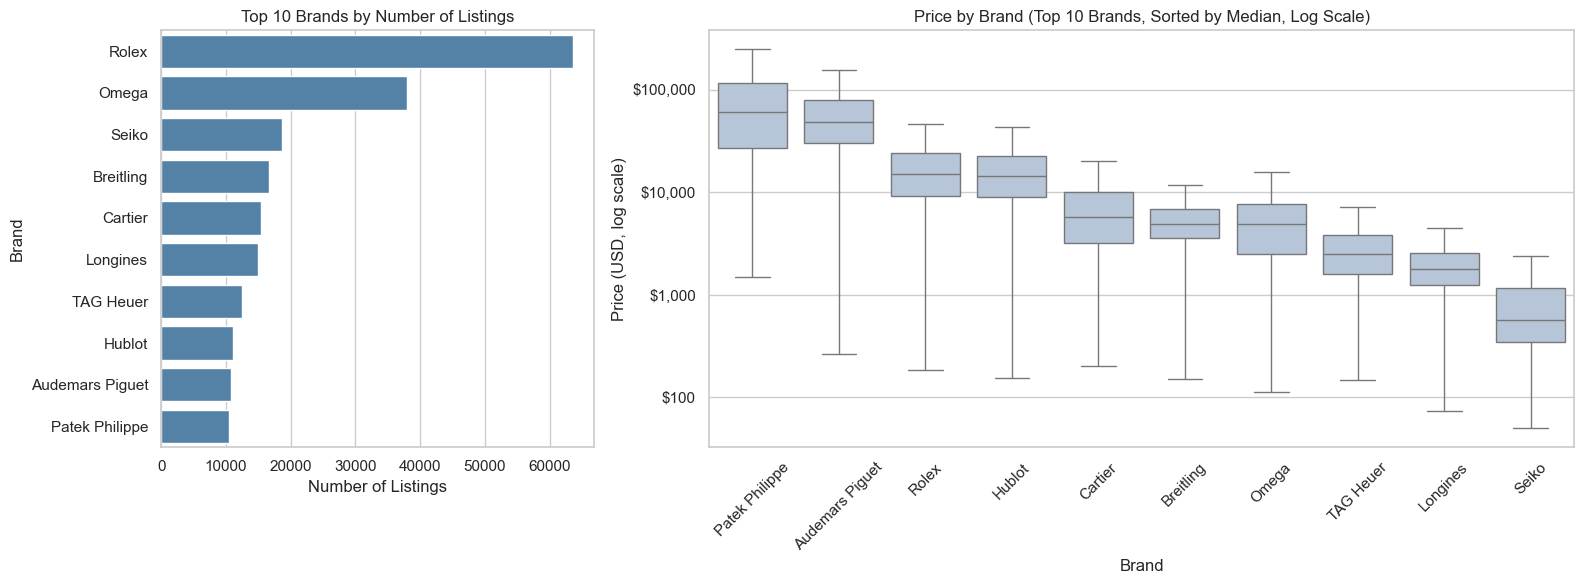

In [81]:
top_brands1 = df1_clean["brand"].value_counts().nlargest(10)
top_brand_listings1 = df1_clean[df1_clean["brand"].isin(top_brands1.index)]
brand_order1 = top_brand_listings1.groupby("brand")["price_clean"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 2]})

sns.barplot(x=top_brands1.values, y=top_brands1.index, color="steelblue", ax=axes[0])
axes[0].set_title("Top 10 Brands by Number of Listings")
axes[0].set_xlabel("Number of Listings")
axes[0].set_ylabel("Brand")

sns.boxplot(data=top_brand_listings1, x="brand", y="price_clean", order=brand_order1,
            color="lightsteelblue", showfliers=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(dollar_format)
axes[1].set_title("Price by Brand (Top 10 Brands, Sorted by Median, Log Scale)")
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Price (USD, log scale)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Observation:** Rolex dominates listing volume. When brands are sorted by median price, the high-end manufacturers (e.g. Patek Philippe, Audemars Piguet) sit well above the rest, with medians several times higher than mid-tier brands. Brand is clearly a major driver of price.

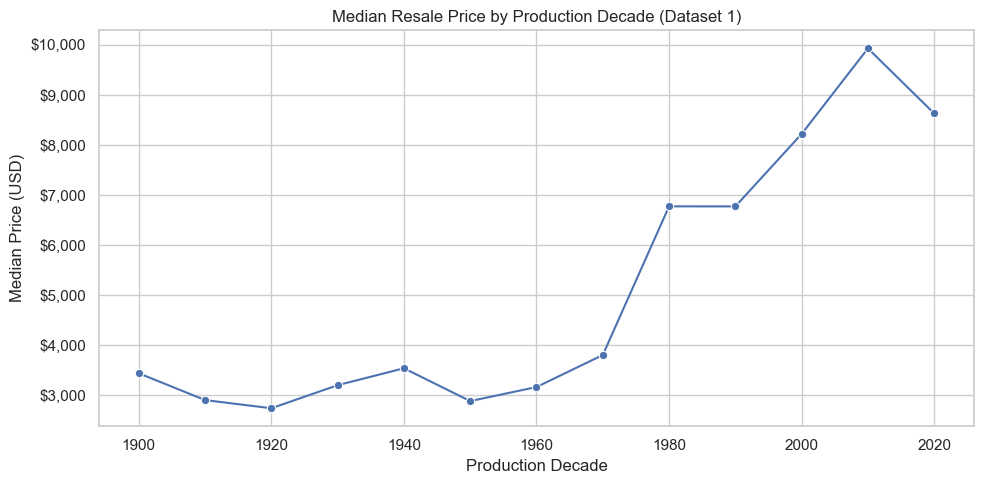

Share of listings with an unknown production year: 33.4%


In [82]:
# Median price by production decade, for listings with a known year
listings_with_year = df1_clean.dropna(subset=["year_clean"]).copy()
listings_with_year["decade"] = (listings_with_year["year_clean"] // 10 * 10).astype(int)
price_by_decade = (
    listings_with_year.groupby("decade")["price_clean"]
    .agg(median_price="median", listings="count")
    .query("listings >= 100")  # skip decades with too few listings to be reliable
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=price_by_decade, x=price_by_decade.index, y="median_price", marker="o", ax=ax)
ax.set_title("Median Resale Price by Production Decade (Dataset 1)")
ax.set_xlabel("Production Decade")
ax.set_ylabel("Median Price (USD)")
ax.yaxis.set_major_formatter(dollar_format)
plt.tight_layout()
plt.show()

print(f"Share of listings with an unknown production year: {df1_clean['year_clean'].isna().mean():.1%}")

**Observation:** Median prices are flat at around $3,000 for watches made before 1970, then jump in the 1980s and peak for watches made in the 2010s. The relationship is clearly **non-linear** (a step, not a straight line). A third of listings have no known production year. The next cell checks whether the jump could be explained by *which* brands are listed from each era.

In [83]:
# Share of listings from the three highest-priced brands (see the brand boxplot above), by decade
high_end_brands = ["Patek Philippe", "Audemars Piguet", "Rolex"]
high_end_share = (
    listings_with_year[listings_with_year["decade"].isin(price_by_decade.index)]
    .groupby("decade")["brand"].apply(lambda brands: brands.isin(high_end_brands).mean())
)
display(high_end_share.rename("share_of_high_end_brands").to_frame().T.style.format("{:.0%}"))

decade,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
share_of_high_end_brands,22%,20%,21%,21%,22%,26%,26%,39%,63%,54%,50%,42%,31%


**Result:** the share of listings from Patek Philippe, Audemars Piguet and Rolex rises from roughly a quarter before 1970 to about 60% in the 1980s, the same decade where the median price jumps. At least part of the "age effect" is therefore a change in brand mix, not age itself.

## 3. Dataset 2: Watch Prices Dataset
This dataset has more structured features (case material, box & papers, gender) and hence will be convenient to be used with some more complex modeling.

### 3.1 Loading and cleaning

In [84]:
df2 = pd.read_csv("data/watches-ds-2.csv")
print(f"Dataset 2 shape: {df2.shape}")
display(df2.head())

Dataset 2 shape: (45024, 23)


,Brand,Movement,Case material,Bracelet material,Year of production,Condition,Scope of delivery,Gender,Price,Availability,...,Crystal,Dial,Bracelet color,Clasp,Watches Sold by the Seller,Active listing of the seller,Fast Shipper,Trusted Seller,Punctuality,Seller Reviews
0,Alpina,Quartz,Steel,Rubber,NaN,New,"Original box, original papers",Men's watch/Unisex,895.0,Item is in stock,...,Sapphire crystal,Black,Black,Buckle,20.0,36.0,0,0,1,15.0
1,Lip,NaN,NaN,NaN,1973.0,Used (Good),"No original box, no original papers",Men's watch/Unisex,701.0,Item is in stock,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,Audemars Piguet,Automatic,Titanium,Titanium,2022.0,Used (Very good),"Original box, original papers",Men's watch/Unisex,39825.0,Item is in stock,...,Sapphire crystal,Grey,NaN,Fold clasp,2.0,48.0,0,1,1,4.0
3,Bulova,Automatic,NaN,NaN,1974.0,Used (Fair),"No original box, no original papers",Men's watch/Unisex,385.0,Item is in stock,...,NaN,Brown,NaN,NaN,NaN,NaN,0,0,0,NaN
4,Philip Watch,Automatic,Yellow gold,Leather,NaN,Like new & unworn,"No original box, no original papers",Men's watch/Unisex,1718.0,Item is in stock,...,NaN,Champagne,Brown,NaN,NaN,NaN,0,0,0,NaN


Cleaning plan:
- Rows with a missing **Price** are dropped (it is the target variable).
- Text columns are stripped of stray whitespace, and missing categorical values are filled with `Unknown`, which keeps these rows and lets the model learn from the fact that the value is missing.
- Exact duplicate rows are removed.
- The cell also measures how much of **Year of production** is missing, to decide how to handle it.

In [85]:
df2 = df2.dropna(subset=["Price"])

categorical_cols2 = ["Brand", "Movement", "Case material", "Condition", "Scope of delivery", "Gender"]
df2[categorical_cols2] = df2[categorical_cols2].apply(lambda col: col.str.strip()).fillna("Unknown")

rows_before = len(df2)
df2 = df2.drop_duplicates()
print(f"Duplicate rows removed: {rows_before - len(df2):,}")
print(f"Share of rows missing 'Year of production': {df2['Year of production'].isna().mean():.1%}")
print(f"Dataset 2 shape after cleaning: {df2.shape}")

Duplicate rows removed: 266
Share of rows missing 'Year of production': 41.3%
Dataset 2 shape after cleaning: (42485, 23)


**Result:** Year of production is missing for about 41% of rows, too many to drop. It is **not** filled here. Instead, a missing-year flag is created during feature engineering, and the median year is filled in inside the modeling pipeline using the training data only, which avoids leaking test-set information.

### 3.2 Outlier analysis
The same rules as Dataset 1 are applied (a $50 floor plus 3 x IQR on log price). For comparison, the cell first shows how much of each top brand the naive raw-price IQR rule would have removed.

In [86]:
raw_low2, raw_high2 = iqr_bounds(df2["Price"], k=1.5)
raw_outlier2 = ~df2["Price"].between(raw_low2, raw_high2)
print(f"Raw-price IQR upper bound: ${raw_high2:,.0f} (would flag {raw_outlier2.mean():.1%} of listings)")
display(
    raw_outlier2.groupby(df2["Brand"]).mean()
    .loc[["Rolex", "Patek Philippe", "Audemars Piguet", "Richard Mille"]]
    .rename("share_flagged_as_outlier").to_frame().style.format("{:.1%}")
)

df2_clean = remove_price_outliers(df2, "Price")
print(f"Dataset 2 shape after outlier removal: {df2_clean.shape}")

Raw-price IQR upper bound: $12,458 (would flag 13.4% of listings)


,share_flagged_as_outlier
Brand,
Rolex,62.1%
Patek Philippe,95.8%
Audemars Piguet,98.2%
Richard Mille,98.5%


Lowest price: $1.00; listings under the $50 floor: 85
Log-scale bounds: $0.87 to $3,722,536
Rows removed: 86 (0.20%)
Dataset 2 shape after outlier removal: (42399, 23)


**Result:** the naive rule would have removed almost every Patek Philippe, Audemars Piguet and Richard Mille listing (and any analysis of them). The log-scale rule, together with the $50 floor (which also removes an implausible $1 listing), removes only a small number of listings.

### 3.3 Feature engineering
New variables are extracted and transformed from the raw columns:
- **`has_box` / `has_papers`**: binary flags parsed from the free-text `Scope of delivery` field. Whether a complete set commands a premium is checked in the EDA below.
- **`watch_age`**: years since production. The reference year is 2024, the latest production year in the data (printed below), since the listings cannot include watches made after they were collected.
- **`year_missing`**: flag for listings with no production year, so "unknown year" can carry its own signal.
- **Rare categories**: brands with fewer than 30 listings and case materials with fewer than 100 are grouped into `Other`. This reduces noise from categories too small to learn from.
- **`log_price`**: `log10(Price)`, the modeling target. The skewness printed below shows why.

In [87]:
print(f"Latest production year in Dataset 2: {df2_clean['Year of production'].max():.0f}")
DATA_COLLECTION_YEAR = 2024
MIN_BRAND_LISTINGS = 30
MIN_MATERIAL_LISTINGS = 100


def group_rare(series, min_count):
    """Replace categories that appear fewer than min_count times with 'Other'."""
    counts = series.value_counts()
    return series.where(series.map(counts) >= min_count, "Other")


scope = df2_clean["Scope of delivery"]
df2_clean["has_box"] = scope.str.startswith("Original box").astype(int)
df2_clean["has_papers"] = (scope.str.contains("original papers", case=False) & ~scope.str.contains("no original papers")).astype(int)
df2_clean["watch_age"] = DATA_COLLECTION_YEAR - df2_clean["Year of production"]
df2_clean["year_missing"] = df2_clean["Year of production"].isna().astype(int)

print(f"Distinct brands before grouping: {df2_clean['Brand'].nunique()}")
df2_clean["Brand"] = group_rare(df2_clean["Brand"], MIN_BRAND_LISTINGS)
df2_clean["Case material"] = group_rare(df2_clean["Case material"], MIN_MATERIAL_LISTINGS)
print(f"Distinct brands after grouping: {df2_clean['Brand'].nunique()}")

df2_clean["log_price"] = np.log10(df2_clean["Price"])
# Skewness of 0 means symmetric; large positive values mean a long right tail
print(f"Skewness of Price: {df2_clean['Price'].skew():.1f}, of log_price: {df2_clean['log_price'].skew():.2f}")

display(df2_clean[["Scope of delivery", "has_box", "has_papers", "Year of production",
                   "watch_age", "year_missing", "Price", "log_price"]].head())

Latest production year in Dataset 2: 2024
Distinct brands before grouping: 479
Distinct brands after grouping: 285
Skewness of Price: 26.9, of log_price: 0.49


,Scope of delivery,has_box,has_papers,Year of production,watch_age,year_missing,Price,log_price
0,"Original box, original papers",1,1,NaN,NaN,1,895.0,2.951823
1,"No original box, no original papers",0,0,1973.0,51.0,0,701.0,2.845718
2,"Original box, original papers",1,1,2022.0,2.0,0,39825.0,4.600156
3,"No original box, no original papers",0,0,1974.0,50.0,0,385.0,2.585461
4,"No original box, no original papers",0,0,NaN,NaN,1,1718.0,3.235023


### 3.4 EDA for Dataset 2

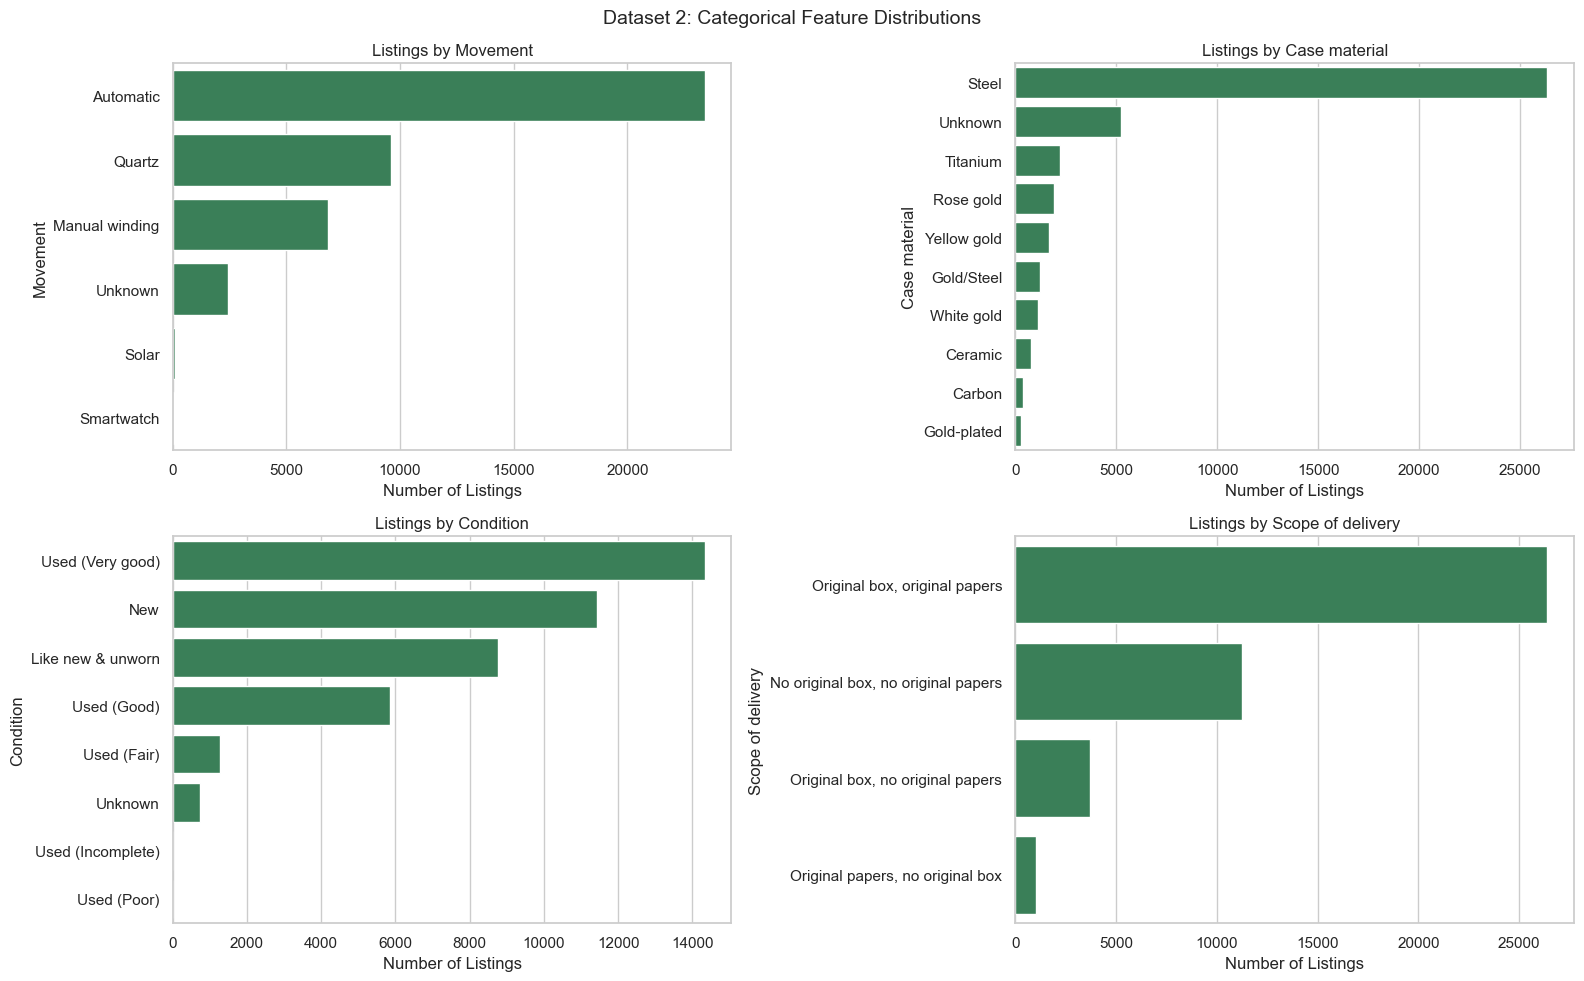

In [88]:
# Distribution of the main categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flat, ["Movement", "Case material", "Condition", "Scope of delivery"]):
    counts = df2_clean[col].value_counts().nlargest(10)
    sns.barplot(x=counts.values, y=counts.index, color="seagreen", ax=ax)
    ax.set_title(f"Listings by {col}")
    ax.set_xlabel("Number of Listings")
    ax.set_ylabel(col)

fig.suptitle("Dataset 2: Categorical Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** Automatic movements and steel cases make up the majority of listings. Most watches are sold in very good or new condition, and most come with both the original box and papers. Categories such as solar or smartwatch movements, and exotic case materials, are rare. This justifies grouping rare categories.

Listings for the 10 most-listed brands: 281 to 293
Median listings per brand: 136


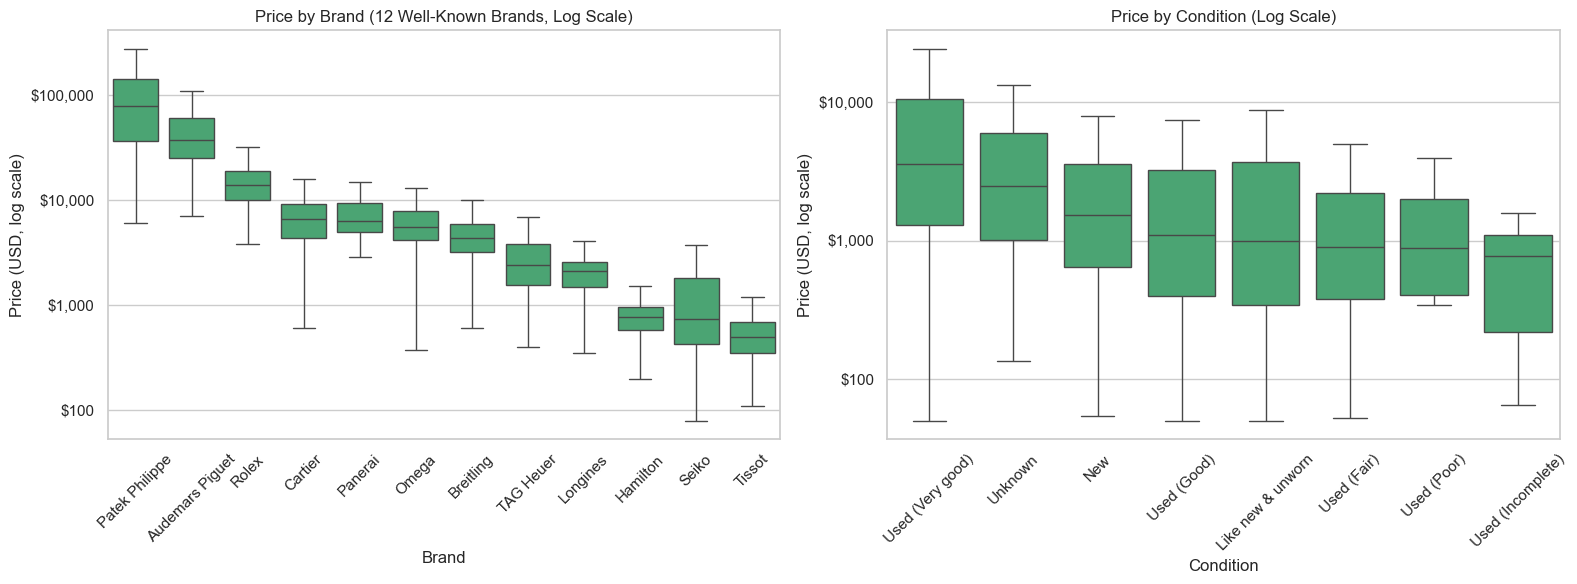

In [89]:
# Listings per brand: the most-listed brands all have a similar count, i.e. the dataset was
# sampled per brand, so "most listed" does not mean most popular
listings_per_brand = df2_clean["Brand"].value_counts().drop("Other")
print(f"Listings for the 10 most-listed brands: {listings_per_brand.iloc[9]} to {listings_per_brand.iloc[0]}")
print(f"Median listings per brand: {listings_per_brand.median():.0f}")

# So instead of the "top 10 by listings", compare a fixed set of well-known brands spanning the price range
well_known_brands = ["Patek Philippe", "Audemars Piguet", "Rolex", "Cartier", "Panerai", "Omega",
                     "Breitling", "TAG Heuer", "Longines", "Hamilton", "Seiko", "Tissot"]
top_brand_listings2 = df2_clean[df2_clean["Brand"].isin(well_known_brands)]
brand_order2 = top_brand_listings2.groupby("Brand")["Price"].median().sort_values(ascending=False).index
condition_order = df2_clean.groupby("Condition")["Price"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=top_brand_listings2, x="Brand", y="Price", order=brand_order2,
            color="mediumseagreen", showfliers=False, ax=axes[0])
axes[0].set_title("Price by Brand (12 Well-Known Brands, Log Scale)")
axes[0].set_ylabel("Price (USD, log scale)")

sns.boxplot(data=df2_clean, x="Condition", y="Price", order=condition_order,
            color="mediumseagreen", showfliers=False, ax=axes[1])
axes[1].set_title("Price by Condition (Log Scale)")
axes[1].set_ylabel("Price (USD, log scale)")

for ax in axes:
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(dollar_format)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Observation:** Brand separates prices far more than condition does. Median prices range from a few hundred dollars (Tissot, Seiko) to about $80,000 (Patek Philippe), a gap of more than 100x, while condition medians all fall between roughly $800 and $4,000. Surprisingly, *Used (Very good)* has a **higher** median than *New*. The next cell checks whether that is a real premium or a brand-mix effect.

In [90]:
# Check 1: how expensive are the brands behind each condition? (median of each listing's brand median)
brand_median_price = df2_clean.groupby("Brand")["Price"].transform("median")
display(
    brand_median_price.groupby(df2_clean["Condition"]).median()
    .sort_values(ascending=False).rename("typical_brand_median_price").to_frame()
    .style.format("${:,.0f}")
)

# Check 2: within the same brand, how often is New priced above Used (Very good)?
new_vs_used = (
    df2_clean[df2_clean["Condition"].isin(["New", "Used (Very good)"]) & (df2_clean["Brand"] != "Other")]
    .groupby(["Brand", "Condition"])["Price"].median().unstack().dropna()
)
new_higher = (new_vs_used["New"] > new_vs_used["Used (Very good)"]).mean()
print(f"Brands where New has a higher median than Used (Very good): {new_higher:.0%} of {len(new_vs_used)}")

,typical_brand_median_price
Condition,
Used (Very good),"$2,665"
Unknown,"$2,092"
Used (Good),"$1,714"
Used (Fair),"$1,627"
New,"$1,459"
Used (Poor),"$1,423"
Like new & unworn,"$1,026"
Used (Incomplete),$686


Brands where New has a higher median than Used (Very good): 76% of 246


**Result:** *Used (Very good)* listings come from brands with a typical median price of about $2,700, nearly twice that of *New* listings (about $1,500). **Within the same brand, New is priced higher than Used (Very good) for 76% of brands.** The higher overall median for *Used (Very good)* is therefore a brand-mix effect, not a premium for wear. This is why a multivariable model is needed to separate the effect of condition from the effect of brand.

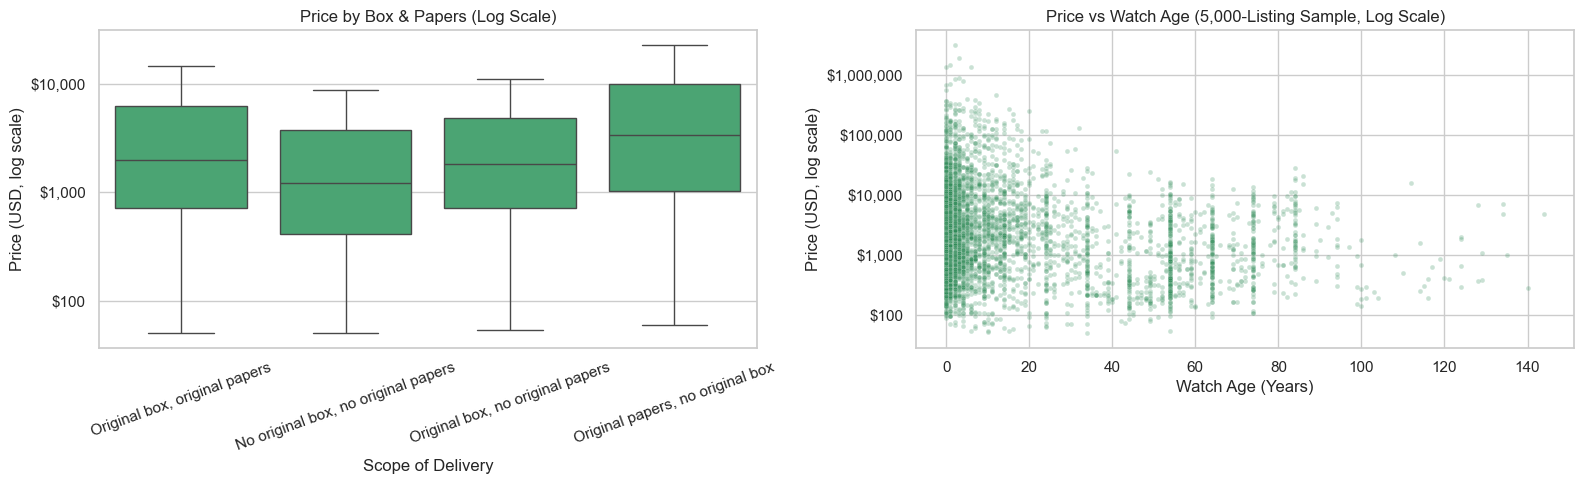

,median_price
Scope of delivery,
"No original box, no original papers","$1,225"
"Original box, no original papers","$1,811"
"Original box, original papers","$2,000"
"Original papers, no original box","$3,357"


Years ending in 0, made before 1990: 54%
Years ending in 0, made 1990 or later: 12%


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df2_clean, x="Scope of delivery", y="Price", color="mediumseagreen",
            showfliers=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(dollar_format)
axes[0].set_title("Price by Box & Papers (Log Scale)")
axes[0].set_xlabel("Scope of Delivery")
axes[0].set_ylabel("Price (USD, log scale)")
axes[0].tick_params(axis="x", rotation=20)

# Continuous vs continuous: watch age against log price (a sample keeps the plot readable)
sample = df2_clean.dropna(subset=["watch_age"]).sample(5000, random_state=42)
sns.scatterplot(data=sample, x="watch_age", y="Price", alpha=0.25, s=12, color="seagreen", ax=axes[1])
axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(dollar_format)
axes[1].set_title("Price vs Watch Age (5,000-Listing Sample, Log Scale)")
axes[1].set_xlabel("Watch Age (Years)")
axes[1].set_ylabel("Price (USD, log scale)")

plt.tight_layout()
plt.show()

display(df2_clean.groupby("Scope of delivery")["Price"].median().sort_values()
        .rename("median_price").to_frame().style.format("${:,.0f}"))

# Share of production years that are round decades (e.g. 1970, 1980), a sign of approximate years
known_years = df2_clean["Year of production"].dropna()
print(f"Years ending in 0, made before 1990: {(known_years[known_years < 1990] % 10 == 0).mean():.0%}")
print(f"Years ending in 0, made 1990 or later: {(known_years[known_years >= 1990] % 10 == 0).mean():.0%}")

**Observation:** Listings with neither box nor papers have the lowest median price, and every group that includes the original **papers** sits higher. Papers appear to matter more than the box, as the papers-only group has the highest median. In the age scatter, most listings are less than 20 years old, and the most expensive watches (above $100,000) are almost all recent. Beyond that, there is no clear linear trend: at every age there are both inexpensive and expensive watches. The vertical bands at ages 24, 34, 44... correspond to production years ending in 0. More than half of pre-1990 years end in 0, versus about 1 in 10 expected, so older watches' years are often rounded estimates.

### 3.5 Steel vs precious metals in top brands
Does a precious metal case always mean a higher resale price? Stainless steel is compared against white, rose and yellow gold for four highly sought-after brands. This analysis uses the log-filtered data, so the expensive end of the market is preserved.

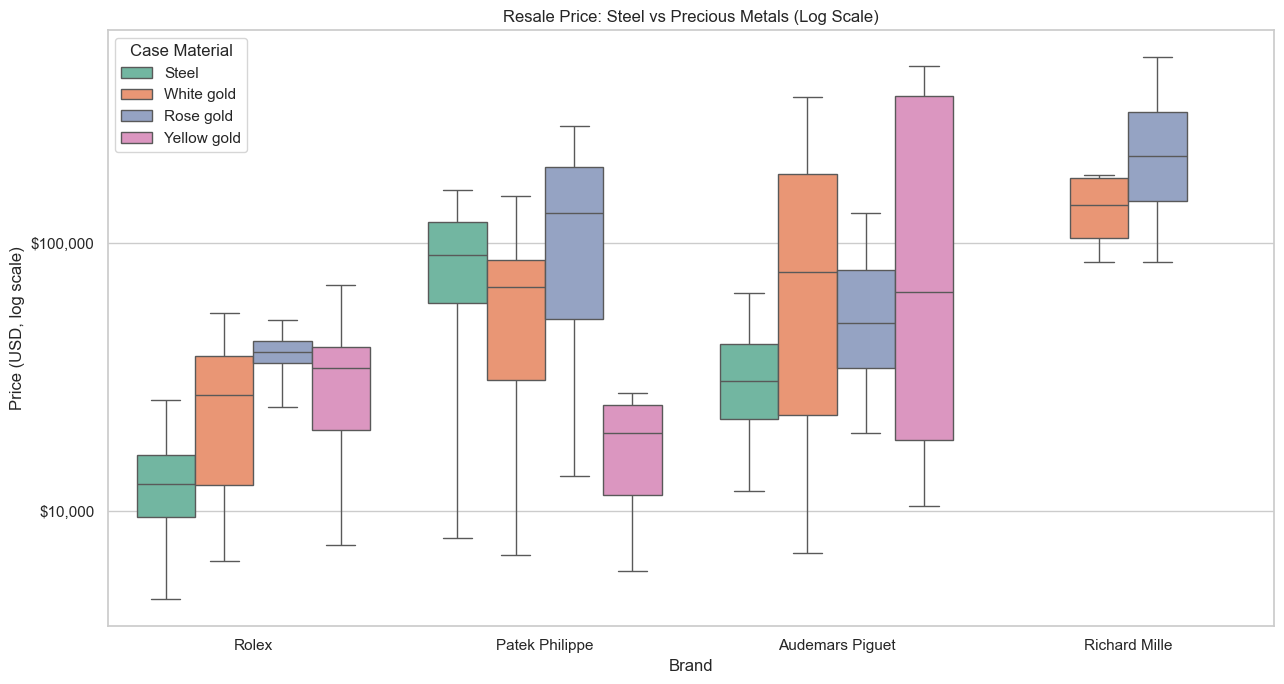

In [92]:
luxury_brands = ["Rolex", "Patek Philippe", "Audemars Piguet", "Richard Mille"]
case_metals = ["Steel", "White gold", "Rose gold", "Yellow gold"]

df_materials = df2_clean[df2_clean["Brand"].isin(luxury_brands) & df2_clean["Case material"].isin(case_metals)]

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(data=df_materials, x="Brand", y="Price", hue="Case material", order=luxury_brands,
            hue_order=case_metals, palette="Set2", showfliers=False, ax=ax)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(dollar_format)
ax.set_title("Resale Price: Steel vs Precious Metals (Log Scale)")
ax.set_xlabel("Brand")
ax.set_ylabel("Price (USD, log scale)")
ax.legend(title="Case Material")
plt.tight_layout()
plt.show()

# Median price and listing count per brand/material, for exact comparison
material_summary = (
    df_materials.groupby(["Brand", "Case material"])["Price"]
    .agg(median_price="median", listings="count")
    .unstack("Case material")
)
display(material_summary.style.format("{:,.0f}", na_rep="-"))

**Observation:** Precious metal usually commands a premium. For Rolex and Audemars Piguet, steel is the *least* expensive case material. **Patek Philippe is the exception:** its steel watches have a higher median resale price than its white gold and yellow gold watches. A possible explanation is demand for Patek's steel sports models (such as the Nautilus), but this dataset has no model names, so that cannot be tested here. Case material therefore interacts with brand: the same material can mean very different prices depending on the manufacturer. Among these four metals, Richard Mille appears mostly in rose gold (its carbon and titanium cases are not shown), and some brand/material combinations have only a handful of listings, so their medians should be read with caution.

## 4. Modeling (Baseline)
### 4.1 Approach and evaluation metrics
- **Target:** `log_price` (`log10` of price). Price is heavily right-skewed (skewness shown in 3.3). With squared-error loss on raw dollars, the few six-figure watches would carry most of the weight. On the log scale, errors are *relative*: being off by $500 on a $1,000 watch counts as much as being off by $50,000 on a $100,000 watch, which fits how buyers and investors think about price.
- **Features:** Brand, Movement, Case material, Condition, Gender (one-hot encoded) plus `watch_age`, `year_missing`, `has_box`, `has_papers`. Missing ages are filled with the training-set median inside the pipeline.
- **Models:** a `DummyRegressor` that always predicts the median price (the naive benchmark), and a **Ridge Regression** baseline. Ridge is a linear, interpretable model whose regularization keeps the hundreds of one-hot brand coefficients stable.

**Evaluation metrics and why they were chosen**
- **R² on log price (primary metric):** the share of variance in (log) price the model explains. It is scale-free and easy to compare against the dummy model (R² of about 0).
- **RMSE on log price:** the typical error in orders of magnitude. RMSE squares errors, so it penalizes large mispricings, which are the costly mistakes for an investor.
- **Median absolute percentage error (in dollars):** translates the error back into plain terms, i.e. how far off a typical prediction is as a percentage of the true price. The median is used because a few extreme listings would dominate the mean.

In [93]:
categorical_features = ["Brand", "Movement", "Case material", "Condition", "Gender"]
numeric_features = ["watch_age", "year_missing", "has_box", "has_papers"]
features = categorical_features + numeric_features

X = df2_clean[features]
y = df2_clean["log_price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", SimpleImputer(strategy="median"), numeric_features),  # fills missing watch_age
])

models = {
    "Dummy (median)": DummyRegressor(strategy="median"),
    "Ridge Regression": Ridge(alpha=1.0),
}

fitted_pipelines = {}
results = []
for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    fitted_pipelines[name] = pipeline

    actual_usd, predicted_usd = 10 ** y_test, 10 ** y_pred
    results.append({
        "Model": name,
        "R² (log price)": r2_score(y_test, y_pred),
        "RMSE (log10 price)": np.sqrt(mean_squared_error(y_test, y_pred)),
        # 10 ** RMSE turns a log10 error into a multiplicative factor (e.g. 2 = off by about 2x)
        "Error factor (10^RMSE)": 10 ** np.sqrt(mean_squared_error(y_test, y_pred)),
        "Median abs % error": np.median(np.abs(predicted_usd - actual_usd) / actual_usd),
        "Median abs error (USD)": np.median(np.abs(predicted_usd - actual_usd)),
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.format({
    "R² (log price)": "{:.3f}",
    "RMSE (log10 price)": "{:.3f}",
    "Error factor (10^RMSE)": "{:.1f}x",
    "Median abs % error": "{:.1%}",
    "Median abs error (USD)": "${:,.0f}",
}))

print(f"Median price in the test set: ${(10 ** y_test).median():,.0f}")

ridge_pipeline = fitted_pipelines["Ridge Regression"]
y_pred_ridge = ridge_pipeline.predict(X_test)

,R² (log price),RMSE (log10 price),Error factor (10^RMSE),Median abs % error,Median abs error (USD)
Model,,,,,
Dummy (median),-0.009,0.702,5.0x,82.7%,"$1,437"
Ridge Regression,0.804,0.309,2.0x,37.3%,$609


Median price in the test set: $1,850


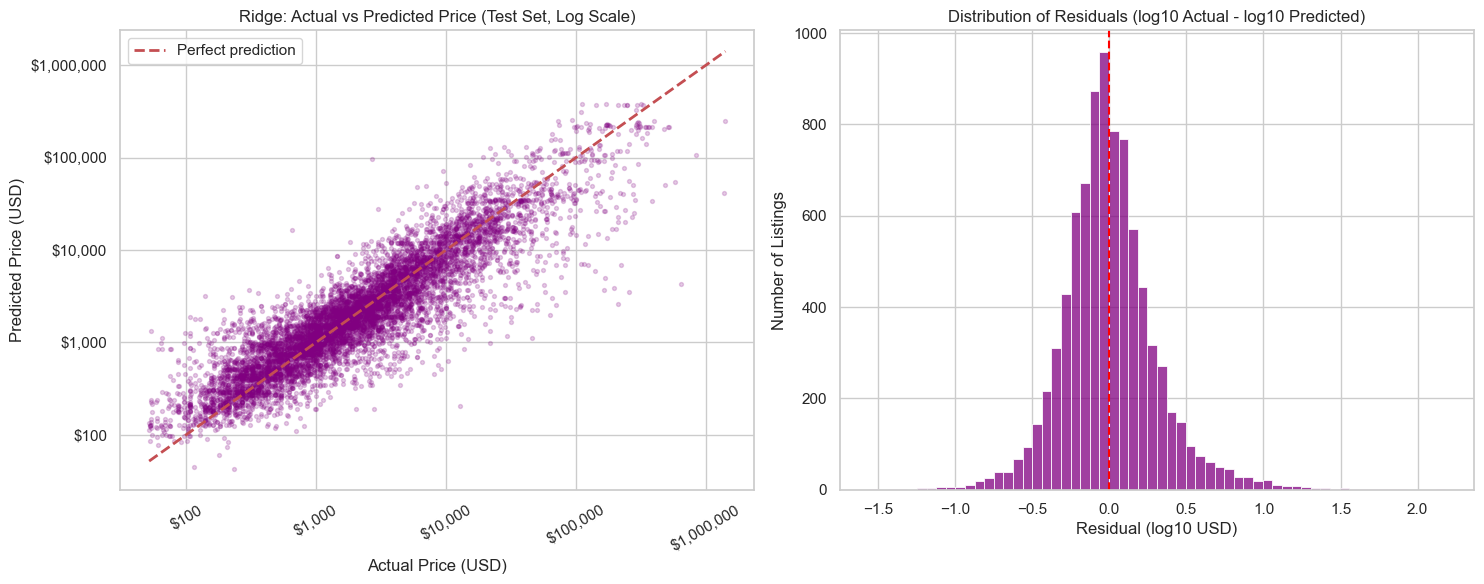

,mean_residual_log10
log_price,
Cheapest 20%,-0.20
2nd,-0.05
3rd,+0.01
4th,+0.07
Priciest 20%,+0.17


In [94]:
residuals = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(10 ** y_test, 10 ** y_pred_ridge, alpha=0.2, s=8, color="purple")
price_range = [10 ** y_test.min(), 10 ** y_test.max()]
axes[0].plot(price_range, price_range, "r--", lw=2, label="Perfect prediction")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].xaxis.set_major_formatter(dollar_format)
axes[0].yaxis.set_major_formatter(dollar_format)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Ridge: Actual vs Predicted Price (Test Set, Log Scale)")
axes[0].set_xlabel("Actual Price (USD)")
axes[0].set_ylabel("Predicted Price (USD)")
axes[0].legend()

sns.histplot(residuals, bins=60, color="purple", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribution of Residuals (log10 Actual - log10 Predicted)")
axes[1].set_xlabel("Residual (log10 USD)")
axes[1].set_ylabel("Number of Listings")

plt.tight_layout()
plt.show()

# Average residual by actual-price quintile: positive = the model under-predicts, negative = over-predicts
price_quintile = pd.qcut(10 ** y_test, q=5, labels=["Cheapest 20%", "2nd", "3rd", "4th", "Priciest 20%"])
display(residuals.groupby(price_quintile, observed=True).mean().rename("mean_residual_log10").to_frame()
        .style.format("{:+.2f}"))

**Observation:** Predictions follow the diagonal across the full price range, from a few hundred dollars to six figures, and the residuals are centred on zero overall. The errors are **not** unbiased at the extremes, however. The quintile table shows the model over-predicts the cheapest watches (negative mean residual) and under-predicts the most expensive ones (positive mean residual): predictions are pulled toward the average price. This is typical of a regularized linear model with limited features, and it means the model may not be as reliable for the high-end watches.

### 4.2 Interpretation of results
- **The Ridge baseline explains about 80% of the variance in log price (R² = 0.80)**, compared to about 0 for the dummy model that always predicts the median. The listed features therefore carry most of the information needed to place a watch in the right price tier.
- **RMSE falls from 0.70 to 0.31 on the log10 scale**, i.e. an error factor of about 2x instead of about 5x (see the error-factor column). Large mispricings still happen, but they are much smaller than with the naive benchmark.
- **The typical (median) prediction is within about 37% of the actual price** (vs 83% for the dummy model), or roughly $600 in absolute terms, against a test-set median price of about $1,850 (printed above).

For a first baseline this is a solid result: the model reliably separates a $500 watch from a $5,000 or $50,000 one. It doesn't seem precise enough, especially at the high end where it under-predicts. Features the dataset lacks, such as model line, reference number and complications, are likely candidates for the remaining error.

### 4.3 Feature importance (permutation importance)
The coefficients of hundreds of one-hot encoded columns (like `Brand_Rolex`) are hard to read, so permutation importance is used instead. It shuffles one *original* feature at a time on the test set and measures how much R² drops.

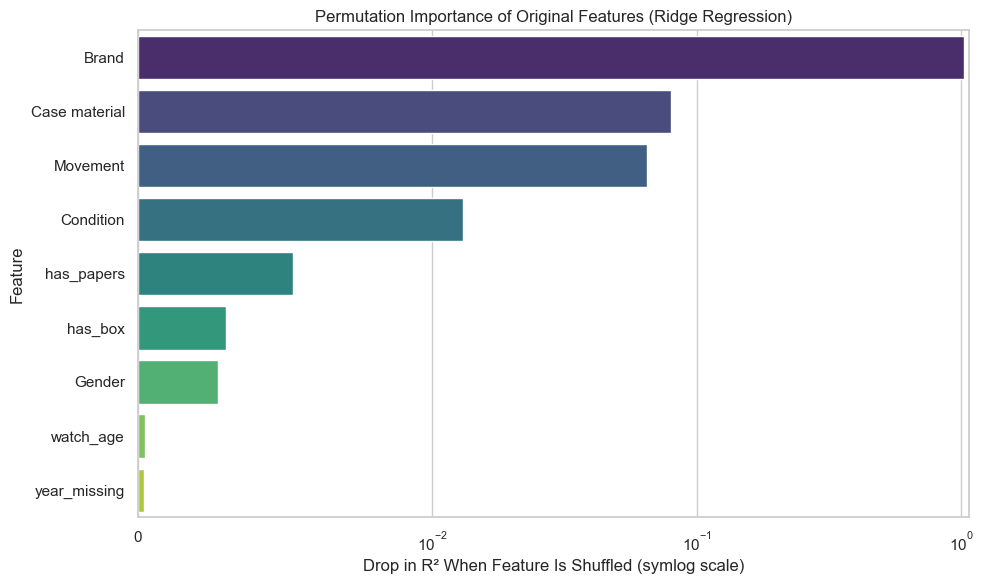

Feature,Importance,Std
Brand,1.0238,0.0174
Case material,0.0800,0.0032
Movement,0.0647,0.0013
Condition,0.0131,0.0012
has_papers,0.0053,0.0005
has_box,0.0030,0.0003
Gender,0.0027,0.0002
watch_age,0.0002,0.0002
year_missing,0.0002,0.0001


In [95]:
importance = permutation_importance(ridge_pipeline, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance.importances_mean,
    "Std": importance.importances_std,
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False, ax=ax)
ax.set_xscale("symlog", linthresh=0.01)  # keeps small importances visible next to Brand
ax.set_title("Permutation Importance of Original Features (Ridge Regression)")
ax.set_xlabel("Drop in R² When Feature Is Shuffled (symlog scale)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance_df.style.format({"Importance": "{:.4f}", "Std": "{:.4f}"}).hide(axis="index"))

In [96]:
# Permutation importance shows HOW MUCH a feature matters, not in which DIRECTION.
# The Ridge coefficients show direction: 10 ** coefficient - 1 is the approximate % price difference
# of each category relative to the model's intercept (all other features held equal); only differences between categories are meaningful.
feature_names = ridge_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.Series(ridge_pipeline.named_steps["model"].coef_, index=feature_names)

for prefix in ["cat__Movement_", "cat__Case material_"]:
    effect = (10 ** coefficients[coefficients.index.str.startswith(prefix)] - 1).sort_values(ascending=False)
    effect.index = effect.index.str.replace(prefix, "", regex=False)
    display(effect.rename(f"{prefix.split('__')[1].rstrip('_')}: price effect").to_frame().style.format("{:+.0%}"))

,Movement: price effect
Manual winding,+53%
Automatic,+31%
Unknown,+21%
Solar,-7%
Quartz,-31%
Smartwatch,-36%


,Case material: price effect
Platinum,+229%
Red gold,+99%
White gold,+92%
Rose gold,+86%
Yellow gold,+47%
Titanium,+13%
Carbon,+6%
Ceramic,+1%
Bronze,-15%
Unknown,-29%


### 4.4 Interpretation of feature importance
- **Brand is by far the most important feature.** Shuffling it drops R² by about 1.0, from 0.80 to below 0, which means the model is almost useless without it.
- **Case material (0.08) and movement (0.06)** are the next most important. The coefficient tables above show the direction: precious metals such as gold and platinum carry a price premium over steel, and quartz movements are priced well below mechanical (automatic and manual) ones.
- **Condition (0.01) and papers (0.005)** have smaller but measurable effects, consistent with the EDA. Box, gender and watch age contribute almost nothing on top of the other features.
- **Why watch age scores near zero:** the age effect is non-linear (see the Dataset 1 decade plot), 41% of years are missing and imputed, and section 2.4 showed in Dataset 1 that part of the age pattern is really a change in brand mix, which the Brand feature already captures. A linear term for age cannot represent this, so its low importance means "not useful in this linear form", **not** "age does not matter". Tree-based models can test this directly.

## 5. Conclusions and Next Steps
**Findings**
1. **Brand dominates resale price.** It explains most of the price variance, and median prices differ by more than 100x between brands.
2. **Case material matters, but interacts with brand.** Precious metals usually command a premium, yet steel Patek Philippe watches have a higher median resale price than white or yellow gold ones.
3. **Movement, condition and original papers** add smaller but consistent effects. Apparent effects in simple comparisons (e.g. used watches priced above new ones) can be brand-mix effects, which the model separates out.
4. **Production year has a non-linear relationship** with price that a linear model does not capture.
5. A Ridge baseline on log price reaches **R² = 0.80** and a **median error of about 37%**, a large improvement over the naive median benchmark.

**Next steps**
- Try non-linear models (Random Forest) with cross-validated hyperparameter tuning, which can capture brand x material interactions and the age effect.
- If possible, combine some features from both datasets, or at least cross reference between the two data sets
- Engineer features from model names and reference numbers (e.g. Nautilus, Daytona, Royal Oak) in Dataset 1, which likely explain much of the remaining error.
- Apply NLP to listing titles and descriptions to capture limited editions and special dials.